# Coverage-matched Student-t HDR volume

This notebook **does not train or recalibrate anything**. It reloads each saved transport and its saved conformal calibrator, jointly estimates the volume and Student-t probability mass of the calibrated transported ball, and compares it with the analytic Student-t HDR at that estimated population mass.

For the forward-image probability mass $c_T$, the reported metric is

$$
L_{\mathrm{HDR}/\mathrm{conf}} = \frac{1}{d}\left[\log \operatorname{Vol}(\mathrm{HDR}_{c_T})-\log \operatorname{Vol}(\mathcal C^{\hat T}_{1-\alpha})\right].
$$

The conformal-region term uses the **saved calibrated radius**, not a population $\chi_d$ radius. Its population mass under the known Student-t target is estimated from the same latent-ball samples as its volume:

$$c_T=\int_{B_{\hat r}} f_t(\hat T(u))|\det J_{\hat T}(u)|\,du.$$

This removes finite-test-set coverage noise from the comparison. With exact integrals, HDR optimality implies $L_{\mathrm{HDR}/\mathrm{conf}}\leq 0$. Both integrals are still Monte Carlo estimates, so their reported standard errors should be checked and very small positive values should not be clipped. Only log-volumes and their normalized log difference are reported.


In [1]:
from __future__ import annotations

import gc
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.auto import tqdm


def find_repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd())
RESULTS_ROOTS = [
    path
    for path in (
        REPOSITORY_ROOT / "results/student_t",
        REPOSITORY_ROOT / "benchmark/results/student_t",
    )
    if path.is_dir()
]
if not RESULTS_ROOTS:
    raise FileNotFoundError("No Student-t results directory was found.")

sys.path.insert(0, str(REPOSITORY_ROOT / "src"))
sns.set_theme(style="whitegrid", context="notebook")

print(f"Repository: {REPOSITORY_ROOT}")
print("Result roots:")
for root in RESULTS_ROOTS:
    print(f"  - {root}")


Repository: <repository-root>
Result roots:
  - benchmark/results/student_t


## Parameters

The default `smoke` scope evaluates one available $d=2$, $k=2$ legacy checkpoint. When the final grid has finished, set `RUN_SCOPE = "new"` to evaluate the `dim_i/k_j/...` hierarchy. Use `legacy` or `all` only when those layouts are intentionally wanted.


In [2]:
RUN_SCOPE = "new"  # one of: "smoke", "new", "legacy", "all"
STAGES = ["base", "rearranged"]
DIMENSIONS = [2, 4, 8, 16, 32]
K_VALUES = [1, 2, 4, 8, 16, 32]
SEEDS = None  # None means every completed seed
NU = 3.0

SMOKE_DIMENSION = 2
SMOKE_K = 2
SMOKE_STAGE = "base"
SMOKE_SEED = 0

# Total uniform-ball samples used jointly for volume and population coverage.
# Increase this when the normalized log fraction is close to zero.
MC_SAMPLES = 100_000
MC_BATCH_SIZE = 1_024
MC_SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVE_RESULTS = False
OUTPUT_CSV = REPOSITORY_ROOT / "notebooks/results/student_t_coverage_matched_volume.csv"

print(f"Device: {DEVICE}")


Device: cpu


## Discover completed runs

A run is considered complete when its config, transport checkpoint, and conformal checkpoint are present. `metrics.json` is not read. Both the final `dim_i/k_j/...` layout and the legacy `nu_3_k_2_y_dim_2/...` layout are recognized.


In [3]:
STAGE_TO_FOLDER = {
    "base": "transport_neural_ot_l2",
    "rearranged": "transport_neural_ot_rearranged_l2",
}
FOLDER_TO_STAGE = {folder: stage for stage, folder in STAGE_TO_FOLDER.items()}


def discover_runs() -> pd.DataFrame:
    records = []
    seen = set()
    for results_root in RESULTS_ROOTS:
        config_paths = {
            *results_root.glob("dim_*/k_*/*/seed_*/config.json"),
            *results_root.glob("nu_*_k_*_y_dim_*/*/seed_*/config.json"),
        }
        for config_path in sorted(config_paths):
            run_directory = config_path.parent
            if run_directory in seen:
                continue
            seen.add(run_directory)

            stage = FOLDER_TO_STAGE.get(run_directory.parent.name)
            if stage is None:
                continue
            model_checkpoint = run_directory / (
                "base/predictor.pt" if stage == "base" else "rearrangement/predictor.pt"
            )
            conformal_checkpoint = run_directory / "conformal/predictor.pt"
            if not all(path.is_file() for path in (model_checkpoint, conformal_checkpoint)):
                continue

            with config_path.open(encoding="utf-8") as file:
                config = json.load(file)
            dataset = config["dataset_config"]
            first_relative_part = run_directory.relative_to(results_root).parts[0]
            records.append({
                "layout": "new" if first_relative_part.startswith("dim_") else "legacy",
                "stage": stage,
                "dimension": int(dataset["y_dim"]),
                "k": float(dataset["k"]),
                "nu": float(dataset["nu"]),
                "seed": int(config["seed"]),
                "run_directory": run_directory,
            })
    return pd.DataFrame(records)


manifest = discover_runs()
if manifest.empty:
    raise FileNotFoundError("No completed Student-t runs were found.")

unknown_stages = set(STAGES) - STAGE_TO_FOLDER.keys()
if unknown_stages:
    raise ValueError(f"Unknown stages: {sorted(unknown_stages)}")

selected = manifest[
    manifest["stage"].isin(STAGES)
    & manifest["dimension"].isin(DIMENSIONS)
    & manifest["k"].isin(K_VALUES)
    & manifest["nu"].eq(NU)
].copy()
if SEEDS is not None:
    selected = selected[selected["seed"].isin(SEEDS)]

if RUN_SCOPE == "smoke":
    selected = manifest[
        manifest["stage"].eq(SMOKE_STAGE)
        & manifest["dimension"].eq(SMOKE_DIMENSION)
        & manifest["k"].eq(float(SMOKE_K))
        & manifest["nu"].eq(NU)
        & manifest["seed"].eq(SMOKE_SEED)
    ].copy()
    # Prefer the final hierarchy if the same smoke run exists in both layouts.
    selected["layout_order"] = selected["layout"].map({"new": 0, "legacy": 1})
    selected = selected.sort_values("layout_order").head(1).drop(columns="layout_order")
elif RUN_SCOPE in {"new", "legacy"}:
    selected = selected[selected["layout"].eq(RUN_SCOPE)]
elif RUN_SCOPE != "all":
    raise ValueError("RUN_SCOPE must be 'smoke', 'new', 'legacy', or 'all'.")

selected = selected.sort_values(["dimension", "k", "stage", "seed"]).reset_index(drop=True)
if selected.empty:
    raise FileNotFoundError("No completed runs match the selected scope and filters.")

print(f"Discovered {len(manifest)} completed runs; selected {len(selected)}.")
display(selected.drop(columns="run_directory"))


Discovered 300 completed runs; selected 300.


,layout,stage,dimension,k,nu,seed
0,new,base,2,1.0,3.0,0
1,new,base,2,1.0,3.0,1
2,new,base,2,1.0,3.0,2
3,new,base,2,1.0,3.0,3
4,new,base,2,1.0,3.0,4
...,...,...,...,...,...,...
295,new,rearranged,32,32.0,3.0,0
296,new,rearranged,32,32.0,3.0,1
297,new,rearranged,32,32.0,3.0,2
298,new,rearranged,32,32.0,3.0,3


## Reload checkpoints and recompute the metric

For every run, the code restores the transport weights and conformal calibrator, including its fitted radius. Uniform samples from the calibrated latent ball are pushed forward once and used for both integrals. There are no metrics-file, optimizer, trainer, `fit`, or `calibrate` calls.


In [4]:
from configs.conformal import TransportBasedConformalPredictorConfig
from configs.predictors.transport import NeuralOptimalTransportPredictorConfig
from conformal import TransportBasedConformalPredictor
from data.datasets.synthetic import StudentTDataset
from experimentation import load_experiment_config
from predictors.rearranged_transport import (
    AmortizedRearrangedTransport,
    RearrangedTransportPredictor,
)
from predictors.transport import NeuralOptimalTransportPredictor


def load_saved_transport(run_directory: Path, stage: str, experiment_config):
    if stage == "base":
        checkpoint_path = run_directory / "base/predictor.pt"
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        config_data = dict(checkpoint["config"])
        config_data["device"] = DEVICE
        predictor_config = NeuralOptimalTransportPredictorConfig.model_validate(config_data)
        predictor = NeuralOptimalTransportPredictor(predictor_config)
        predictor.load_state_dict(checkpoint["state_dict"])
    else:
        checkpoint_path = run_directory / "rearrangement/predictor.pt"
        rearrangement_config = experiment_config.rearrangement_config
        if rearrangement_config is None:
            raise ValueError("A rearranged run has no rearrangement config.")
        predictor_classes = {
            "amortized_rearranged_transport": AmortizedRearrangedTransport,
            "rearranged_transport": RearrangedTransportPredictor,
        }
        predictor = predictor_classes[rearrangement_config.type].load(
            str(checkpoint_path), map_location=DEVICE
        )
    predictor.eval()
    return predictor, checkpoint_path


def load_saved_conformal_predictor(run_directory: Path, predictor):
    checkpoint = torch.load(
        run_directory / "conformal/predictor.pt",
        map_location=DEVICE,
        weights_only=False,
    )
    conformal_config = TransportBasedConformalPredictorConfig.model_validate(
        checkpoint["config"]
    )
    conformal_predictor = TransportBasedConformalPredictor(
        predictor=predictor, config=conformal_config
    )
    conformal_predictor.calibrator = checkpoint["calibrator"]
    if not conformal_predictor.is_calibrated:
        raise RuntimeError("The saved conformal predictor is not calibrated.")
    return conformal_predictor


def relative_mc_standard_error(
    log_sum: torch.Tensor,
    log_sum_of_squares: torch.Tensor,
    number_of_samples: int,
) -> float:
    log_mean = log_sum - math.log(number_of_samples)
    log_second_moment = log_sum_of_squares - math.log(number_of_samples)
    log_relative_second_moment = float(log_second_moment - 2.0 * log_mean)
    try:
        relative_variance = max(0.0, math.expm1(log_relative_second_moment))
    except OverflowError:
        return math.inf
    return math.sqrt(relative_variance / number_of_samples)


def estimate_region_log_volume_and_coverage(
    conformal_predictor,
    dataset,
    number_of_samples: int,
    batch_size: int,
    seed: int,
) -> dict:
    if (
        isinstance(number_of_samples, bool)
        or not isinstance(number_of_samples, int)
        or number_of_samples < 1
    ):
        raise ValueError("MC_SAMPLES must be a positive integer.")
    if (
        isinstance(batch_size, bool)
        or not isinstance(batch_size, int)
        or batch_size < 1
    ):
        raise ValueError("MC_BATCH_SIZE must be a positive integer.")

    radius = torch.as_tensor(
        conformal_predictor.threshold,
        device=conformal_predictor.device,
        dtype=conformal_predictor.dtype,
    )
    if radius.ndim != 0 or not torch.isfinite(radius) or radius <= 0.0:
        raise ValueError("The saved conformal radius must be a positive scalar.")

    sampling_device = (
        conformal_predictor.device
        if conformal_predictor.device.type in {"cpu", "cuda"}
        else torch.device("cpu")
    )
    generator = torch.Generator(device=sampling_device)
    generator.manual_seed(seed)

    log_volume_sum = torch.tensor(-torch.inf, dtype=torch.float64)
    log_volume_square_sum = torch.tensor(-torch.inf, dtype=torch.float64)
    log_mass_sum = torch.tensor(-torch.inf, dtype=torch.float64)
    log_mass_square_sum = torch.tensor(-torch.inf, dtype=torch.float64)

    completed = 0
    while completed < number_of_samples:
        chunk_size = min(batch_size, number_of_samples - completed)
        directions = torch.randn(
            chunk_size, conformal_predictor.y_dim,
            device=sampling_device, dtype=conformal_predictor.dtype,
            generator=generator,
        )
        directions = directions / directions.norm(dim=-1, keepdim=True).clamp_min(
            torch.finfo(conformal_predictor.dtype).eps
        )
        radial_fractions = torch.rand(
            chunk_size, 1, device=sampling_device,
            dtype=conformal_predictor.dtype, generator=generator,
        ).pow(1.0 / conformal_predictor.y_dim)
        latent = (
            radius.to(sampling_device) * radial_fractions * directions
        ).to(device=conformal_predictor.device, dtype=conformal_predictor.dtype)
        x = dataset.sample_x(chunk_size)

        observations = conformal_predictor.pushforward(x=x, u=latent)
        log_det = conformal_predictor.log_det(x=x, u=latent).reshape(-1)
        target_log_density = dataset.log_prob(x=x, y=observations).reshape(-1)
        if log_det.numel() != chunk_size or target_log_density.numel() != chunk_size:
            raise ValueError("Expected one Jacobian and density value per sample.")
        if not torch.isfinite(log_det).all() or not torch.isfinite(target_log_density).all():
            raise RuntimeError("The coverage integral contains non-finite values.")

        log_det = log_det.detach().to(device="cpu", dtype=torch.float64)
        log_mass_integrand = log_det + target_log_density.detach().to(
            device="cpu", dtype=torch.float64
        )
        log_volume_sum = torch.logaddexp(log_volume_sum, torch.logsumexp(log_det, dim=0))
        log_volume_square_sum = torch.logaddexp(
            log_volume_square_sum, torch.logsumexp(2.0 * log_det, dim=0)
        )
        log_mass_sum = torch.logaddexp(
            log_mass_sum, torch.logsumexp(log_mass_integrand, dim=0)
        )
        log_mass_square_sum = torch.logaddexp(
            log_mass_square_sum, torch.logsumexp(2.0 * log_mass_integrand, dim=0)
        )
        completed += chunk_size

    radius_value = float(radius.detach().cpu())
    log_ball_volume = (
        conformal_predictor.y_dim * math.log(radius_value)
        + 0.5 * conformal_predictor.y_dim * math.log(math.pi)
        - math.lgamma(0.5 * conformal_predictor.y_dim + 1.0)
    )
    log_volume = log_ball_volume + float(log_volume_sum) - math.log(number_of_samples)
    log_coverage = log_ball_volume + float(log_mass_sum) - math.log(number_of_samples)
    coverage = math.exp(log_coverage)
    if not 0.0 < coverage < 1.0:
        raise RuntimeError(
            f"Estimated population coverage must lie in (0, 1), got {coverage}. "
            "Increase MC_SAMPLES if this is Monte Carlo error."
        )

    volume_relative_se = relative_mc_standard_error(
        log_volume_sum, log_volume_square_sum, number_of_samples
    )
    coverage_relative_se = relative_mc_standard_error(
        log_mass_sum, log_mass_square_sum, number_of_samples
    )
    return {
        "log_volume": log_volume,
        "coverage": coverage,
        "coverage_mc_standard_error": coverage * coverage_relative_se,
        "log_volume_mc_standard_error": volume_relative_se,
    }


def evaluate_run(run: dict) -> dict:
    run_directory = Path(run["run_directory"])
    experiment_config = load_experiment_config(run_directory / "config.json")
    predictor, checkpoint_path = load_saved_transport(
        run_directory, run["stage"], experiment_config
    )
    conformal_predictor = load_saved_conformal_predictor(run_directory, predictor)
    dataset_config = experiment_config.dataset_config.model_copy(update={"device": DEVICE})
    dataset = StudentTDataset(dataset_config)

    integral = estimate_region_log_volume_and_coverage(
        conformal_predictor=conformal_predictor,
        dataset=dataset,
        number_of_samples=MC_SAMPLES,
        batch_size=MC_BATCH_SIZE,
        seed=MC_SEED,
    )
    estimated_coverage = integral["coverage"]
    conformal_log_volume = integral["log_volume"]
    hdr_log_volume = float(dataset.hdr(alpha=1.0 - estimated_coverage).log_volume)
    if not all(math.isfinite(value) for value in (hdr_log_volume, conformal_log_volume)):
        raise RuntimeError("A recomputed log-volume is not finite.")

    dimension = int(run["dimension"])
    normalized_log_fraction = (hdr_log_volume - conformal_log_volume) / dimension
    threshold = float(torch.as_tensor(conformal_predictor.threshold).detach().cpu().item())
    return {
        "layout": run["layout"],
        "stage": run["stage"],
        "dimension": dimension,
        "k": float(run["k"]),
        "nu": float(run["nu"]),
        "seed": int(run["seed"]),
        "nominal_coverage": float(conformal_predictor.coverage_mass),
        "estimated_region_coverage": estimated_coverage,
        "coverage_mc_standard_error": integral["coverage_mc_standard_error"],
        "coverage_error": estimated_coverage - float(conformal_predictor.coverage_mass),
        "hdr_log_volume_at_estimated_coverage": hdr_log_volume,
        "conformal_region_log_volume": conformal_log_volume,
        "log_volume_mc_standard_error": integral["log_volume_mc_standard_error"],
        "normalized_log_hdr_fraction": normalized_log_fraction,
        "nonpositive_as_theory_predicts": normalized_log_fraction <= 0.0,
        "calibrated_ball_radius": threshold,
        "mc_samples": int(MC_SAMPLES),
        "checkpoint": str(checkpoint_path.relative_to(REPOSITORY_ROOT)),
    }


records = []
failures = []
for run in tqdm(selected.to_dict(orient="records"), desc="Recomputing saved runs"):
    try:
        records.append(evaluate_run(run))
    except Exception as error:
        failures.append({
            "run_directory": str(Path(run["run_directory"]).relative_to(REPOSITORY_ROOT)),
            "error_type": type(error).__name__,
            "error": str(error),
        })
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results = pd.DataFrame(records)
failure_table = pd.DataFrame(failures)

if results.empty:
    display(failure_table)
    raise RuntimeError("Every selected checkpoint failed during recomputation.")

if SAVE_RESULTS:
    results.to_csv(OUTPUT_CSV, index=False)
    print(f"Saved {OUTPUT_CSV}")

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


Recomputing saved runs:   0%|          | 0/300 [00:00<?, ?it/s]

## Per-run results

Values closer to zero are closer to the population-mass-matched HDR optimum. Negative values indicate that the predicted region is larger than the HDR on the normalized log scale. The two Monte Carlo standard errors diagnose whether more samples are needed; positive values are flagged rather than silently truncated.


In [27]:
# result_columns = [
#     "layout", "stage", "dimension", "k", "seed",
#     "nominal_coverage", "estimated_region_coverage",
#     "coverage_mc_standard_error", "coverage_error",
#     "hdr_log_volume_at_estimated_coverage", "conformal_region_log_volume",
#     "log_volume_mc_standard_error",
#     "normalized_log_hdr_fraction", "nonpositive_as_theory_predicts",
#     "calibrated_ball_radius", "mc_samples",
# ]

result_columns = [
    "coverage_mc_standard_error", "estimated_region_coverage", "dimension", "k", "seed",
    "normalized_log_hdr_fraction", "log_volume_mc_standard_error", "mc_samples"
]

results = results.sort_values(["dimension", "k", "stage", "seed"]).reset_index(drop=True)
display(results[result_columns])

positive_count = int((results["normalized_log_hdr_fraction"] > 0.0).sum())
print(f"Positive diagnostics: {positive_count}/{len(results)} runs")
if not failure_table.empty:
    print(f"Failed recomputations: {len(failure_table)}")
    display(failure_table)

,coverage_mc_standard_error,estimated_region_coverage,dimension,k,seed,normalized_log_hdr_fraction,log_volume_mc_standard_error,mc_samples
0,0.001771,0.887911,2,1.0,0,-0.006442,0.001265,100000
1,0.001786,0.897613,2,1.0,1,-0.006386,0.001352,100000
2,0.002037,0.914817,2,1.0,2,-0.008573,0.001455,100000
3,0.001730,0.885419,2,1.0,3,-0.004883,0.001338,100000
4,0.001919,0.910722,2,1.0,4,-0.006392,0.001446,100000
...,...,...,...,...,...,...,...,...
290,0.138779,0.984395,32,32.0,2,-0.965614,0.998924,100000
291,0.081913,0.946973,32,32.0,0,-0.608795,0.988113,100000
292,0.120706,0.927932,32,32.0,1,-0.718083,0.565938,100000
293,0.101577,0.891341,32,32.0,2,-0.929094,0.709249,100000


Positive diagnostics: 71/295 runs
Failed recomputations: 5


,run_directory,error_type,error
0,benchmark/results/student_t/dim_32/k_16/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
1,benchmark/results/student_t/dim_32/k_16/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
2,benchmark/results/student_t/dim_32/k_32/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
3,benchmark/results/student_t/dim_32/k_32/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
4,benchmark/results/student_t/dim_32/k_32/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."


In [28]:
results[results[result_columns].k == 1][result_columns].groupby(by=["dimension", "k"]).median()

,,coverage_mc_standard_error,estimated_region_coverage,seed,normalized_log_hdr_fraction,log_volume_mc_standard_error,mc_samples
dimension,k,,,,,,
2,1.0,0.001802,0.899396,2.0,-0.006389,0.001359,100000.0
4,1.0,0.003183,0.904538,2.0,0.008274,0.002174,100000.0
8,1.0,0.005595,0.893323,2.0,-0.027792,0.003119,100000.0
16,1.0,0.014444,0.902862,2.0,0.007517,0.004856,100000.0
32,1.0,0.053758,0.930678,2.0,0.059703,0.014388,100000.0


In [29]:
results[results[result_columns].k == 1][result_columns]

,coverage_mc_standard_error,estimated_region_coverage,dimension,k,seed,normalized_log_hdr_fraction,log_volume_mc_standard_error,mc_samples
0,0.001771,0.887911,2,1.0,0,-0.006442,0.001265,100000
1,0.001786,0.897613,2,1.0,1,-0.006386,0.001352,100000
2,0.002037,0.914817,2,1.0,2,-0.008573,0.001455,100000
3,0.001730,0.885419,2,1.0,3,-0.004883,0.001338,100000
4,0.001919,0.910722,2,1.0,4,-0.006392,0.001446,100000
5,0.001774,0.888555,2,1.0,0,-0.006221,0.001261,100000
6,0.001819,0.901180,2,1.0,1,-0.006206,0.001366,100000
7,0.002015,0.913253,2,1.0,2,-0.007569,0.001433,100000
8,0.001740,0.887366,2,1.0,3,-0.005215,0.001343,100000
9,0.001941,0.912762,2,1.0,4,-0.006449,0.001454,100000


In [9]:
if not failure_table.empty:
    print(f"Failed recomputations: {len(failure_table)}")
    display(failure_table)

Failed recomputations: 5


,run_directory,error_type,error
0,benchmark/results/student_t/dim_32/k_16/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
1,benchmark/results/student_t/dim_32/k_16/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
2,benchmark/results/student_t/dim_32/k_32/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
3,benchmark/results/student_t/dim_32/k_32/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."
4,benchmark/results/student_t/dim_32/k_32/transp...,RuntimeError,"Estimated population coverage must lie in (0, ..."


## Across-seed summary

The table reports the median and interquartile range for both the normalized log fraction and integral-estimated population coverage.


In [7]:
summary = (
    results.groupby(["stage", "dimension", "k"], as_index=False)
    .agg(
        metric_q25=("normalized_log_hdr_fraction", lambda values: values.quantile(0.25)),
        metric_median=("normalized_log_hdr_fraction", "median"),
        metric_q75=("normalized_log_hdr_fraction", lambda values: values.quantile(0.75)),
        coverage_q25=("estimated_region_coverage", lambda values: values.quantile(0.25)),
        coverage_median=("estimated_region_coverage", "median"),
        coverage_q75=("estimated_region_coverage", lambda values: values.quantile(0.75)),
        runs=("seed", "size"),
    )
)
display(summary.round(6))


,stage,dimension,k,metric_q25,metric_median,metric_q75,coverage_q25,coverage_median,coverage_q75,runs
0,base,2,1.0,-0.006442,-0.006392,-0.006386,0.887911,0.897613,0.910722,5
1,base,2,2.0,-0.006732,-0.006551,-0.006427,0.886258,0.899356,0.910628,5
2,base,2,4.0,-0.008299,-0.007908,-0.007689,0.887411,0.900714,0.909091,5
3,base,2,8.0,-0.010835,-0.010664,-0.010435,0.883868,0.899015,0.907567,5
4,base,2,16.0,-0.015741,-0.014611,-0.013645,0.886783,0.897757,0.905442,5
5,base,2,32.0,-0.021373,-0.019541,-0.019093,0.886995,0.894611,0.906068,5
6,base,4,1.0,0.006881,0.007468,0.009473,0.898629,0.904651,0.905111,5
7,base,4,2.0,0.005114,0.005315,0.007725,0.895845,0.905863,0.907836,5
8,base,4,4.0,-0.001569,-0.000093,0.000442,0.899027,0.908280,0.911851,5
9,base,4,8.0,-0.013562,-0.013015,-0.012423,0.903578,0.907429,0.910370,5


## Dimension and conditioning-number exploration

Lines show across-seed medians and shaded bands show the interquartile range. The upper dashed line in the metric panel is the theoretical population bound; the coverage panel's dashed line is the nominal conformal coverage.


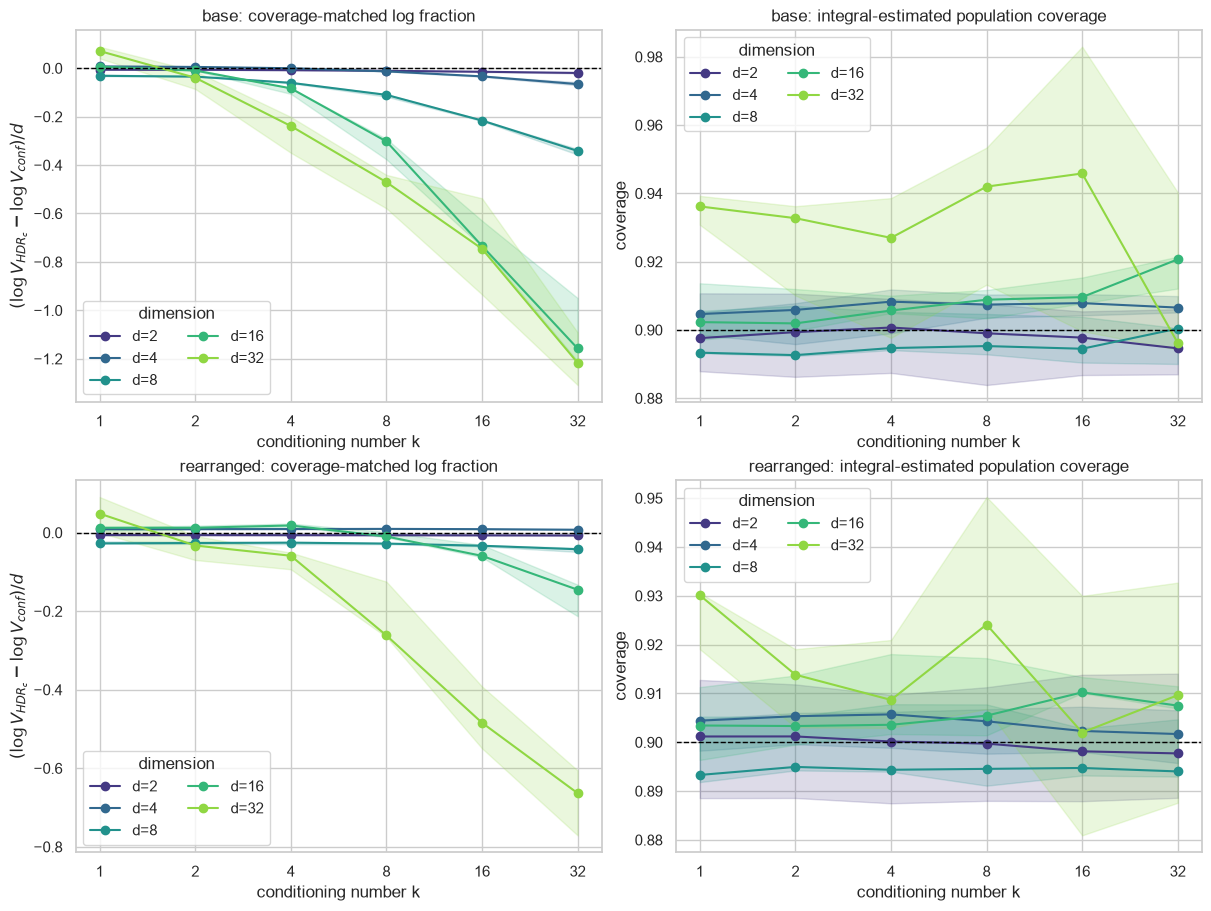

In [8]:
available_stages = [stage for stage in STAGES if stage in set(summary["stage"])]
figure, axes = plt.subplots(
    len(available_stages), 2,
    figsize=(12, 4.5 * len(available_stages)),
    squeeze=False,
    constrained_layout=True,
)
palette = dict(zip(sorted(summary["dimension"].unique()), sns.color_palette("viridis", summary["dimension"].nunique())))

for row_axes, stage in zip(axes, available_stages):
    stage_summary = summary[summary["stage"].eq(stage)]
    metric_axis, coverage_axis = row_axes
    for dimension, dimension_summary in stage_summary.groupby("dimension"):
        dimension_summary = dimension_summary.sort_values("k")
        color = palette[dimension]
        x = dimension_summary["k"].to_numpy(dtype=float)
        metric_axis.plot(
            x, dimension_summary["metric_median"], marker="o",
            color=color, label=f"d={dimension}",
        )
        metric_axis.fill_between(
            x, dimension_summary["metric_q25"], dimension_summary["metric_q75"],
            color=color, alpha=0.18,
        )
        coverage_axis.plot(
            x, dimension_summary["coverage_median"], marker="o",
            color=color, label=f"d={dimension}",
        )
        coverage_axis.fill_between(
            x, dimension_summary["coverage_q25"], dimension_summary["coverage_q75"],
            color=color, alpha=0.18,
        )

    metric_axis.axhline(0.0, color="black", linestyle="--", linewidth=1)
    metric_axis.set_title(f"{stage}: coverage-matched log fraction")
    metric_axis.set_ylabel(r"$(\log V_{HDR_c}-\log V_{conf})/d$")
    coverage_axis.axhline(
        results.loc[results["stage"].eq(stage), "nominal_coverage"].median(),
        color="black", linestyle="--", linewidth=1,
    )
    coverage_axis.set_title(f"{stage}: integral-estimated population coverage")
    coverage_axis.set_ylabel("coverage")

    for axis in row_axes:
        axis.set_xscale("log", base=2)
        axis.set_xticks(sorted(stage_summary["k"].unique()))
        axis.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        axis.set_xlabel("conditioning number k")
        axis.legend(title="dimension", ncols=2)

plt.show()
